In [1]:
import cornac
from cornac.data import Reader
from cornac.datasets import movielens
from cornac.data import Dataset, FeatureModality
from cornac.eval_methods import RatioSplit, StratifiedSplit
from cornac.metrics import RMSE, AUC, NDCG, Precision, Recall
from cornac.models import MF, ItemKNN, UserKNN, NMF, BPR, LightGCN, SVD, MostPop, VAECF
import pandas as pd
import numpy as np
import random
import math
from collections import OrderedDict
import seaborn as sns
import matplotlib.pyplot as plt

/Users/tahsinalamgirkheya/anaconda3/envs/cornac/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
reader = Reader()
rating_data_pd = pd.read_csv(
    "./cornac/data_c/indexed_interactions.csv",
    sep="\t",
    header=None,
    names=["userID", "itemID", "Rating", "Timestamp"],
)
rating_data = rating_data_pd.to_numpy()
rating_data.__len__()
rating_data_pd


,userID,itemID,Rating,Timestamp
0,0,0,5,978300760
1,0,1,3,978302109
2,0,2,3,978301968
3,0,3,4,978300275
4,0,4,5,978824291
...,...,...,...,...
999606,6039,772,1,956716541
999607,6039,1106,5,956704887
999608,6039,365,5,956704746
999609,6039,152,4,956715648


In [3]:

movies = pd.read_csv("./cornac/data_c/indexed_movies.csv")

movies = movies.drop(columns=movies.columns[0])
movies[:4]

unique_genres = [
    "Action",
    "Thriller",
    "Romance",
    "Western",
    "Children's",
    "Mystery",
    "Fantasy",
    "Film-Noir",
    "Documentary",
    "Comedy",
    "Adventure",
    "Sci-Fi",
    "Horror",
    "Crime",
    "Musical",
    "War",
    "Animation",
    "Drama",
]
for genre in unique_genres:
    movies[genre] = 0
for index, row in movies.iterrows():
    genres = row["genres"].split("|")
    for genre in genres:
        movies.at[index, genre] = 1

genre = movies[unique_genres]
item_features_numpy = genre.to_numpy()
item_features = {
    str(item_id): {"genre_" + str(idx): value for idx, value in enumerate(row)}
    for item_id, row in enumerate(item_features_numpy)
}
ids = list(range(0, 3416))

users = pd.read_csv("./cornac/data_c/u_id_mapping.csv", sep="\t")
users = users.drop(columns=users.columns[0])
gender_map = {"M": 0, "F": 1}
users["Gender"] = users["Gender"].map(gender_map)
user_features_numpy = users.to_numpy()
print(user_features_numpy.shape)
print(item_features_numpy.shape)

(6040, 2)
(3416, 18)


In [4]:
dataset = rating_data
unique_genres.__len__()

18

In [5]:

movies = movies.sort_values(by="itemID")
movies

,movieID,genres,itemID,Action,Thriller,Romance,Western,Children's,Mystery,Fantasy,...,Documentary,Comedy,Adventure,Sci-Fi,Horror,Crime,Musical,War,Animation,Drama
0,1193,Drama,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,661,Animation|Children's|Musical,1,0,0,0,0,1,0,0,...,0,0,0,0,0,0,1,0,1,0
2,914,Musical|Romance,2,0,0,1,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
3,3408,Drama,3,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,2355,Animation|Children's|Comedy,4,0,0,0,0,1,0,0,...,0,1,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3411,2833,Romance|War,3411,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3412,3207,Adventure,3412,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
3413,3533,Drama,3413,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3414,2777,Drama,3414,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [6]:
users
user_features_numpy[:,1]

array([   0,    1,    2, ..., 6037, 6038, 6039])

In [7]:
# inter_movies = pd.merge(rating_data_pd, movies, on="itemID", how="inner")
# inter_movies = pd.merge(inter_movies, users, on="userID", how="inner")
# inter_movies
# dataset = Dataset.from_uirt(rating_data, reader=reader)
dataset = rating_data
unique_genres.__len__()

18

In [ ]:
n_seed = 123
ratio_split = StratifiedSplit(
    data=dataset,
    test_size=0.2,
    rating_threshold=0,
    val_size=0.1,
    seed=n_seed,
    verbose=True,
    chrono=True,
    user_features=user_features_numpy[:, 0],
    item_features=item_features_numpy,
    exclude_unknowns=False,
)
rec_50 = cornac.metrics.Recall(k=50)
ndcg_50 = cornac.metrics.NDCG(k=50)
auc = cornac.metrics.AUC()
rmse = cornac.metrics.RMSE()
prec = cornac.metrics.Precision(k=50)
hr = cornac.metrics.HitRatio(k=50)
mrr = cornac.metrics.MRR()
map = cornac.metrics.MAP()
f1 = cornac.metrics.FMeasure(k=50)


models = []

alpha_values = [0, 0.1,0.2,0.3,0.4,0.5,0.6]
# alpha_values =[0]
for i in range(len(alpha_values)):
    # learning
    models.append(
       MF(
            k=40,
            seed=n_seed,
            name=f"a={alpha_values[i]} mf",
            backend="pytorch",
            verbose=True,
            optimizer="adam",batch_size=1024,
            alpha=alpha_values[i],
            learning_rate=0.001,
            top_k=50, max_iter=23,
            # early_stopping=True, 
            run_mode="bce"
        )
    )



# models = [model_1, model_2, model_3, model_4, model_5]
cornac.Experiment(
    ratio_split, models=models, metrics=[rec_50, ndcg_50, auc, rmse, prec, hr, mrr, map, f1]
).run()

# seed 123 e23


rating_threshold = 0.0
exclude_unknowns = False
::::::::
OrderedDict()
OrderedDict()
::::::::
---
Training data:
(array([   0,    0,    0, ..., 6039, 6039, 6039]), array([   0,    1,    2, ..., 2136, 1874,  734]), array([4., 5., 4., ..., 4., 5., 4.]))
Number of users = 6040
Number of items = 3415
Number of ratings = 694578
Max rating = 5.0
Min rating = 1.0
Global mean = 3.6
Global mean Imolicit= 1.0
::::::::
OrderedDict([(6039, 0), (6038, 1), (6037, 2), (6036, 3), (6035, 4), (6034, 5), (6033, 6), (6032, 7), (6031, 8), (6030, 9), (6029, 10), (6028, 11), (6027, 12), (6026, 13), (6025, 14), (6024, 15), (6023, 16), (6022, 17), (6021, 18), (6020, 19), (6019, 20), (6018, 21), (6017, 22), (6016, 23), (6015, 24), (6014, 25), (6013, 26), (6012, 27), (6011, 28), (6010, 29), (6009, 30), (6008, 31), (6006, 32), (6007, 33), (6005, 34), (6004, 35), (6003, 36), (6002, 37), (6001, 38), (6000, 39), (5999, 40), (5998, 41), (5997, 42), (5996, 43), (5995, 44), (5994, 45), (5993, 46), (5992, 47), (5991, 48

100%|██████████| 23/23 [03:23<00:00,  8.83s/it, loss=0.289]


[709.7781372070312, 709.556396484375, 709.3492431640625, 709.1583251953125, 708.97412109375, 708.5842895507812, 708.3519897460938, 708.2086791992188, 707.9474487304688, 707.6021728515625, 707.3438720703125, 707.2474365234375, 706.7404174804688, 706.84814453125, 706.340576171875, 706.0036010742188, 705.8599243164062, 705.5352783203125, 705.2313842773438, 705.0721435546875, 704.5283813476562, 704.8228759765625, 704.495361328125, 704.12158203125, 703.8339233398438, 703.5936889648438, 703.3975830078125, 703.356201171875, 702.9506225585938, 702.7880859375, 702.1048583984375, 702.0523071289062, 701.36962890625, 701.510009765625, 701.565673828125, 700.9644775390625, 701.2999877929688, 700.1644287109375, 701.3250122070312, 699.9295654296875, 700.502685546875, 699.720458984375, 699.725830078125, 698.8464965820312, 699.3910522460938, 698.568359375, 698.4165649414062, 697.5855102539062, 698.2033081054688, 697.6368408203125, 697.2176513671875, 697.376708984375, 696.416748046875, 696.7167358398438,

Ranking: 100%|██████████| 6040/6040 [00:04<00:00, 1243.87it/s]



[a=0.1 mf] Training started!


100%|██████████| 23/23 [35:27<00:00, 92.51s/it, loss=0.427] 


[673.5253295898438, 673.3328247070312, 673.2018432617188, 673.0366821289062, 672.8961791992188, 672.5473022460938, 672.3828125, 672.3489990234375, 672.0961303710938, 671.805419921875, 671.6608276367188, 671.5828247070312, 671.2449951171875, 671.257080078125, 670.9339599609375, 670.57666015625, 670.4425048828125, 670.320068359375, 669.972900390625, 669.7969970703125, 669.43212890625, 669.726806640625, 669.400390625, 669.2320556640625, 668.9492797851562, 668.83984375, 668.6929321289062, 668.9007568359375, 668.328369140625, 668.3357543945312, 667.7515869140625, 667.7120971679688, 667.0394287109375, 667.5130004882812, 667.4203491210938, 666.79296875, 667.311767578125, 666.306884765625, 667.2058715820312, 666.0980834960938, 666.6447143554688, 666.1539916992188, 665.9396362304688, 665.359130859375, 665.8900146484375, 665.4144287109375, 665.0297241210938, 664.4879150390625, 664.6765747070312, 664.5189208984375, 664.2120971679688, 664.3572998046875, 663.6670532226562, 664.1917724609375, 664.04

Ranking: 100%|██████████| 6040/6040 [00:04<00:00, 1436.77it/s]



[a=0.2 mf] Training started!


 35%|███▍      | 8/23 [11:24<21:10, 84.70s/it, loss=0.527]

In [24]:
perf_string = """
               |   RMSE |    AUC |  F1@50 | HitRatio@50 |    MAP |    MRR | NDCG@50 | Precision@50 | Recall@50 | Train (s) | Test (s)
-------- + ------ + ------ + ------ + ----------- + ------ + ------ + ------- + ------------ + --------- + --------- + --------
a=0 mf   | 1.3753 | 0.8641 | 0.0961 |      0.8485 | 0.0854 | 0.2856 |  0.1522 |       0.0911 |    0.1698 |  268.8878 |   8.2389
a=0.1 mf | 1.2031 | 0.8589 | 0.0940 |      0.8522 | 0.0830 | 0.2763 |  0.1489 |       0.0885 |    0.1693 | 2069.6127 |   7.3091
a=0.2 mf | 1.0914 | 0.8523 | 0.0897 |      0.8483 | 0.0790 | 0.2662 |  0.1418 |       0.0847 |    0.1607 | 6577.3087 |   6.7544
a=0.3 mf | 1.0559 | 0.8462 | 0.0849 |      0.8386 | 0.0748 | 0.2602 |  0.1347 |       0.0804 |    0.1519 | 3863.4176 |   6.5114
a=0.4 mf | 1.0524 | 0.8402 | 0.0802 |      0.8255 | 0.0704 | 0.2450 |  0.1259 |       0.0766 |    0.1408 | 2156.2206 |   6.5805
a=0.5 mf | 1.0599 | 0.8339 | 0.0771 |      0.8169 | 0.0690 | 0.2494 |  0.1236 |       0.0737 |    0.1350 | 2036.3519 |   7.0035
a=0.6 mf | 1.0700 | 0.8265 | 0.0739 |      0.8136 | 0.0644 | 0.2437 |  0.1169 |       0.0706 |    0.1289 | 1882.8612 |   6.3810

"""
def extract_columns(table: str, col_names: tuple):
    """
    Extract columns named in col_names from the ASCII table in `table`.
    Returns list of lists corresponding to each column.
    """
    lines = [ln for ln in table.splitlines() if ln.strip() != ""]
    # find header line (contains known header tokens like 'RMSE' or 'HitRatio')
    header_idx = None
    for i, ln in enumerate(lines):
        if 'RMSE' in ln and 'HitRatio' in ln:
            header_idx = i
            break
    if header_idx is None:
        raise ValueError("Header line not found in table")

    # find separator line after header (line with dash or +)
    sep_idx = None
    for j in range(header_idx+1, len(lines)):
        if set(lines[j].strip()) <= set("-+ "):
            sep_idx = j
            break
    if sep_idx is None:
        # fallback: assume header_idx is followed immediately by data
        sep_idx = header_idx

    header_line = lines[header_idx]
    data_lines = lines[sep_idx+1:]

    # split header into column names
    headers = [h.strip() for h in header_line.split('|')]
    # find indices for requested columns
    idxs = []
    for cname in col_names:
        try:
            idx = headers.index(cname)
        except ValueError:
            # try more tolerant matching (case-insensitive / substring)
            found = False
            for k, h in enumerate(headers):
                if cname.lower() in h.lower():
                    idxs.append(k)
                    found = True
                    break
            if not found:
                raise ValueError(f"Column '{cname}' not found in header: {headers}")
        else:
            idxs.append(idx)

    # parse data rows
    results = [[] for _ in col_names]
    for dl in data_lines:
        parts = [p.strip() for p in dl.split('|')]
        # skip lines that don't have enough columns
        if len(parts) <= max(idxs):
            continue
        for out_list, idx in zip(results, idxs):
            val_str = parts[idx]
            # remove accidental commas and convert to float
            try:
                val = float(val_str.replace(',', ''))
            except ValueError:
                # if there are extra spaces or non-numeric, try to extract numeric substring
                import re
                m = re.search(r"[-+]?\d*\.\d+|\d+", val_str)
                if m:
                    val = float(m.group(0))
                else:
                    raise
            out_list.append(val)
    return results

if __name__ == "__main__":
    hit_list, ndcg_list = extract_columns(perf_string, ("HitRatio@50", "NDCG@50"))
    print("HitRatio@50:", hit_list)
    print("NDCG@50:   ", ndcg_list)
    assert len(hit_list) == 7 and len(ndcg_list) == 7, "Expected 7 rows each"

HitRatio@50: [0.8485, 0.8522, 0.8483, 0.8386, 0.8255, 0.8169, 0.8136]
NDCG@50:    [0.1522, 0.1489, 0.1418, 0.1347, 0.1259, 0.1236, 0.1169]


In [12]:
models

In [ ]:
# ratio_split = StratifiedSplit(
#     data=dataset,
#     test_size=0.2,
#     rating_threshold=0.0,
#     seed=123,
#     verbose=True,
#     chrono=True,
#     user_features=user_features_numpy[:, 0],
#     item_features=item_features_numpy,
#     exclude_unknowns=False,
# )
# rec_50 = cornac.metrics.Recall(k=50)
# ndcg_50 = cornac.metrics.NDCG(k=50)
# auc = cornac.metrics.AUC()
# rmse = cornac.metrics.RMSE()
# prec = cornac.metrics.Precision(k=50)
# hr = cornac.metrics.HitRatio(k=50)
# mrr = cornac.metrics.MRR()
# map = cornac.metrics.MAP()


# models = []
# # alpha_values = [0, 0.1,1,10]

# alpha_values = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]
# # alpha_values = [10000,0]
# # alpha_values =[0,0.5]
# # alpha_values = [0,10,50,100, 500,1000,1500, 2000 , 2500, 3000, 4000, 5000, 5500, 60000, 7000, 7500, 8000, 9000, 10000, 200000 ]
# # alpha_values = [0, 0.5,0.8,1]
# # alpha_values =[0,0.8]

# # lr_values = [0.01]
# # alpha_values = [ 0,  0.1,    1,     10,   100,    500,    750,     1000,    2000,   3000,    5000, 7500, 10000]
# # alpha_values = [0,   0.1]
# # lr_values =    [0.0005, 0.0009, 0.0007, 0.0007, 0.0006, 0.0005, 0.0004, 0.0003, 0.0002, 0.0001, 0.00005, 0.00003, 0.00001]
# alpha_values=[0.5]

# #kheyarocks
# for i in range(len(alpha_values)):
#     # learning
#     models.append(
#         MF(
#             k=20,
#             seed=123,
#             name=f"a={alpha_values[i]} mf",
#             backend="pytorch",
#             verbose=True,
#             optimizer="adam",
#             alpha=alpha_values[i],
#             learning_rate=0.001,
#             top_k=50, max_iter=100
#         )
#     )
# # models.append(MF(
# #     k=20,
# #     seed=123,
# #     name=f"a={0} mf",
# #     backend="pytorch",
# #     verbose=True,
# #     optimizer="adam",
# #     alpha=0,top_k=50,
# #     learning_rate=0.01,
# # ))
# # models.append(MF(
# #     k=20,
# #     seed=123,
# #     name=f"a={0.4} mf",
# #     backend="pytorch",
# #     verbose=True,
# #     optimizer="adam",top_k=50,
# #     alpha=0.4,
# #     learning_rate=0.1,
# # ))


# # models = [model_1, model_2, model_3, model_4, model_5]
# cornac.Experiment(
#     ratio_split, models=models, metrics=[rec_50, ndcg_50, auc, rmse, prec, hr, mrr, map]
# ).run()

In [13]:
user_ids = users.to_numpy()[:, 1]
item_ids = movies.to_numpy()[:, 2]
item_ids.__len__()

3416

In [ ]:
# # get the top_k ratings for all users:
# top_k = 20
# reco_matrix = np.zeros((len(user_ids), top_k), dtype=int)
# reco_matrix_all_scores = np.zeros((len(user_ids), len(item_ids)), dtype=int)
# reco_matrix_all_items = np.zeros((len(user_ids), len(item_ids)), dtype=int)

# for i in range(len(user_ids)):
#     reco_items, all_scores = models[0].rank(user_idx=user_ids[i], item_indices=list(item_ids))
#     reco_matrix[i] = reco_items[:top_k]
#     reco_matrix_all_scores[i] = all_scores
#     reco_matrix_all_items[i] = reco_items

In [ ]:
# reco_matrix_reco = np.zeros((len(user_ids),top_k), dtype=int)

# for i in range(len(user_ids)):
#     reco_matrix_reco[i] = models[0].recommend(user_ids[i])[:top_k]

In [ ]:
# reco_matrix_new = np.zeros((len(user_ids), top_k), dtype=int)

# for i in range(len(user_ids)):
#     reco_matrix_new[i] = reco_matrix_reco[i][:top_k]

# reco_matrix_new
reco_matrix[0][3]

In [14]:
# get the top_k ratings for all users:
top_k = 50
reco_matrix = np.zeros((len(models), len(user_ids), top_k), dtype=int)
reco_matrix_mapped_items = np.zeros(
    (len(models), len(user_ids), len(item_ids)), dtype=int
)
reco_matrix_mapped_scores = np.zeros(
    (len(models), len(user_ids), len(item_ids)), dtype=float
)
reco_matrix_all = np.zeros((len(models), len(user_ids), len(item_ids)), dtype=int)


for u in user_ids:
    for i in range(len(models)):
        reco_items = models[i].recommend(u)
        items_mapped, mapped_scores = models[i].rank(
            user_idx=u, item_indices=list(item_ids)
        )
        reco_matrix_mapped_items[i][u] = items_mapped
        reco_matrix_mapped_scores[i][u] = mapped_scores
        reco_matrix_all[i][u] = reco_items
        reco_matrix[i][u] = reco_items[:top_k]

        # print(reco_matrix[0][3])

In [15]:
reco_matrix.shape

(7, 6040, 50)

In [ ]:
reco_matrix[0][1]


array([104, 124,  44,  64, 127,  22, 128,  48,  51,  23, 669,   5, 246,
        97, 113,  92, 134, 132, 184, 244,  38, 167,  26, 116, 189, 217,
        40, 209,  84, 171, 273,   0, 259, 420, 434, 151,  67, 381, 743,
         9,  60, 206, 662, 714,  15, 213,  62, 105, 277, 733])

In [16]:
np.save("reco_matrix_1m.npy", reco_matrix)
# np.save("reco_matrix_mapped_items.npy", reco_matrix_mapped_items)
# np.save("reco_matrix_mapped_scores.npy", reco_matrix_mapped_scores)
np.save("reco_matrix_all_1m.npy", reco_matrix_all)
# np.save("reco_items_scores_all.npy", reco_items_scores_all)

# reco_matrix_all_items

In [17]:
####Import Metrics####
from cornac.mymetrics.GenrePrecision import GenrePrecision
from cornac.mymetrics.GenreMapEdited import GenreMapEdited
from cornac.mymetrics.GenreMRR import GenreMRR
from cornac.mymetrics.GenreNDCG import GenreNDCG
from cornac.mymetrics.GenreRecall import GenreRecall
from cornac.mymetrics.GenreRPrecision import GenreRPrecision

top_k = 50
###intialize them
gp = GenrePrecision(users, unique_genres, top_k)
gr = GenreRecall(users, unique_genres, top_k)
gm = GenreMapEdited(users, unique_genres, top_k)
gndcg = GenreNDCG(users, unique_genres, top_k)
gmrr = GenreMRR(users, unique_genres, top_k)

In [18]:
# for r-precision we wanna take the max of the proportiion of total genre in the movie dataset using ranks
movies_df = movies[unique_genres].div(movies[unique_genres].sum(axis=1), axis=0)
movies_df = movies_df[unique_genres].sum()
new_top_k = math.floor(movies_df.max())


# get the top_k ratings for all users:
reco_matrix_top_r = np.zeros((len(models), len(user_ids), new_top_k), dtype=int)

for u in range(len(user_ids)):
    for i in range(len(models)):
        # reco_items, all_scores = models[i].rank(user_idx=user_ids[i], item_indices=list(item_ids))
        reco_matrix_top_r[i][u] = reco_matrix_all[i][u][:new_top_k]


grp = GenreRPrecision(users, unique_genres, top_k)
# MF_grp = grp.compute(reco_matrix_top_r, movies_df, movies)

In [ ]:
# # for r-precision we wanna take the max of the proportiion of total genre in the movie dataset using ranks
# movies_df = movies[unique_genres].div(movies[unique_genres].sum(axis=1), axis=0)
# movies_df = movies_df[unique_genres].sum()
# new_top_k = math.floor(movies_df.max())


# # get the top_k ratings for all users:
# reco_matrix_top_r = np.zeros((3, len(user_ids), new_top_k), dtype=int)

# for u in range(len(user_ids)):
#     for i in range(3):
#         # reco_items, all_scores = models[i].rank(user_idx=user_ids[i], item_indices=list(item_ids))
#         reco_matrix_top_r[i][u] = reco_matrix_all[i][u][:new_top_k]


# grp = GenreRPrecision(users, unique_genres, top_k)
# # MF_grp = grp.compute(reco_matrix_top_r, movies_df, movies)

In [ ]:
reco_matrix_top_r[0][0].__len__()
models.__len__()

In [ ]:
# # for r-precision we wanna take the max of the proportiion of total genre in the movie dataset using ranks
# movies_df = movies[unique_genres].div(movies[unique_genres].sum(axis=1), axis=0)
# movies_df = movies_df[unique_genres].sum()
# new_top_k = math.floor(movies_df.max())


# # get the top_k ratings for all users:
# reco_matrix_top_r = np.zeros((len(user_ids), new_top_k), dtype=int)

# for i in range(len(user_ids)):
#     reco_matrix_top_r[i] = models[0].recommend(user_ids[i])[:new_top_k]


# grp = GenreRPrecision(users, unique_genres)
# # MF_grp = grp.compute(reco_matrix_top_r, movies_df, movies)

In [19]:
####IR Metrics####
model_gps = []
model_grs = []
model_gms = []
model_gdcgs = []
model_gmrrs = []

for i in range(len(models)):
    ####Precision####
    model_gps.append(gp.compute(reco_matrix[i], movies))
    ####Recall####
    model_grs.append(gr.compute(reco_matrix[i], movies))
    ####MAP Mean Average Precision####
    model_gms.append(gm.compute(reco_matrix[i], movies))
    ####DCG####
    model_gdcgs.append(gndcg.compute(reco_matrix[i], movies))
    ####MRR####
    model_gmrrs.append(gmrr.compute(reco_matrix[i], movies))


# model_gp = gp.compute(reco_matrix[0], movies)
# model_gp_2 = gp.compute(reco_matrix[1], movies)
# model_gp_3 = gp.compute(reco_matrix[2], movies)
# model_gp_4 = gp.compute(reco_matrix[3], movies)
# model_gp_5 = gp.compute(reco_matrix[4], movies)


####IR Metrics####
# model_gr = gr.compute(reco_matrix[0], movies)
# model_gr_2 = gr.compute(reco_matrix[1], movies)
# model_gr_3 = gr.compute(reco_matrix[2], movies)
# model_gr_4 = gr.compute(reco_matrix[3], movies)
# model_gr_5 = gr.compute(reco_matrix[4], movies)
####IR Metrics####
####MAP Mean Average Precision####
# model_gm = gm.compute(reco_matrix[0], movies)
# model_gm_2 = gm.compute(reco_matrix[1], movies)
# model_gm_3 = gm.compute(reco_matrix[2], movies)
# model_gm_4 = gm.compute(reco_matrix[3], movies)
# model_gm_5 = gm.compute(reco_matrix[4], movies)
####IR Metrics####
####DCG####
# model_gdcg = gndcg.compute(reco_matrix[0], movies)
# model_gdcg_2 = gndcg.compute(reco_matrix[1], movies)
# model_gdcg_3 = gndcg.compute(reco_matrix[2], movies)
# model_gdcg_4 = gndcg.compute(reco_matrix[3], movies)
# model_gdcg_5 = gndcg.compute(reco_matrix[4], movies)
####IR Metrics####
####MRR####
# model_gmrr = gmrr.compute(reco_matrix[0], movies)
# model_gmrr_2 = gmrr.compute(reco_matrix[1], movies)
# model_gmrr_3 = gmrr.compute(reco_matrix[2], movies)
# model_gmrr_4 = gmrr.compute(reco_matrix[3], movies)
# model_gmrr_5 = gmrr.compute(reco_matrix[4], movies)

In [ ]:
movies_df

Action          96.966667
Thriller       105.933333
Romance        101.850000
Western         16.250000
Children's      49.050000
Mystery         23.283333
Fantasy          5.766667
Film-Noir        7.833333
Documentary     25.000000
Comedy         282.000000
Adventure       50.133333
Sci-Fi          39.500000
Horror          55.266667
Crime           39.450000
Musical         23.816667
War             27.566667
Animation       16.550000
Drama          381.783333
dtype: float64

In [20]:
# ####IR Metrics####
# ####Rprecision####
model_grps = []
for i in range(len(models)):
    model_grps.append(grp.compute(reco_matrix_top_r[i], movies_df, movies))
# model_grp = grp.compute(reco_matrix_top_r[0], movies_df, movies)
# model_grp_2 = grp.compute(reco_matrix_top_r[1], movies_df, movies)
# model_grp_3 = grp.compute(reco_matrix_top_r[2], movies_df, movies)
# model_grp_4 = grp.compute(reco_matrix_top_r[3], movies_df, movies)
# model_grp_5 = grp.compute(reco_matrix_top_r[4], movies_df, movies)

          Action  Thriller   Romance   Western  Children's   Mystery  \
Gender                                                                 
0       0.122702  0.092644  0.055347  0.001256    0.019567  0.009972   
1       0.096084  0.082820  0.070755  0.001133    0.023435  0.009762   

         Fantasy  Film-Noir  Documentary    Comedy  Adventure    Sci-Fi  \
Gender                                                                    
0       0.018327   0.010213     0.000212  0.211953   0.057265  0.088578   
1       0.015949   0.009254     0.000316  0.228704   0.047112  0.066788   

          Horror     Crime   Musical       War  Animation     Drama  
Gender                                                               
0       0.033270  0.036767  0.003294  0.043043   0.010895  0.214183  
1       0.026988  0.034083  0.005687  0.041566   0.014677  0.233377  
[[1.22702244e-01 9.26435607e-02 5.53470279e-02 1.25576892e-03
  1.95671869e-02 9.97230701e-03 1.83265529e-02 1.02133369e-02
  2.12

In [ ]:
from operator import itemgetter

# unique_genres
indices = [0, 1, 2, 11, 17]
compare_genres = itemgetter(*indices)(unique_genres)
# compare_genres = unique_genres
# indices = range(18)
list(compare_genres)

['Action', 'Thriller', 'Romance', 'Sci-Fi', 'Drama']

In [ ]:
x = model_gps[0]
models.__len__()

11

In [ ]:
sum(abs(model_gdcgs[0]))

0.018365975447228865

In [21]:
gp_sum = [sum(abs(model_gps[i])) for i in range(len(models))]
gr_sum = [sum(abs(model_grs[i])) for i in range(len(models))]
gm_sum = [sum(abs(model_gms[i])) for i in range(len(models))]
gdcg_sum = [sum(abs(model_gdcgs[i])) for i in range(len(models))]
gmrr_sum = [sum(abs(model_gmrrs[i])) for i in range(len(models))]
grp_sum = [sum(abs(model_grps[i])) for i in range(len(models))]


In [ ]:
len(gp_sum)

11

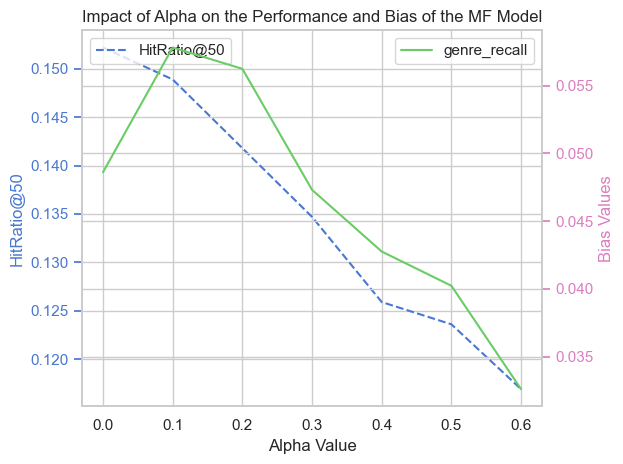

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns


x = alpha_values
upper_bound = len(alpha_values)
titles = [
    "genre_precision",
    "genre_recall",
    "genre_map",
    "genre_dcg",
    "genre_mrr",
    "genre_r_precision",
]
sns.set(style="whitegrid")
pastel_palette = sns.color_palette("muted")

fig, ax1 = plt.subplots()

ax1.plot(x[0:upper_bound], ndcg_list[0:upper_bound], linestyle="--", color=pastel_palette[0], label="HitRatio@50")
# ax1.plot(x[0:upper_bound], auc_values_extracted[0:upper_bound], linestyle="dotted", color=pastel_palette[0], label="RMSE")
ax1.set_xlabel("Alpha Value")
ax1.set_ylabel("HitRatio@50", color=pastel_palette[0])
ax1.tick_params(axis="y", colors=pastel_palette[0])
ax2 = ax1.twinx()
# ax2.plot(x[0:upper_bound], gp_sum[0:upper_bound], label=titles[0], color=pastel_palette[1])
ax2.plot(x[0:upper_bound], gr_sum[0:upper_bound], label=titles[1], color=pastel_palette[2])
# ax2.plot(x[0:upper_bound], gm_sum[0:upper_bound], label=titles[2], color=pastel_palette[3])
# ax2.plot(x[0:upper_bound], gdcg_sum[0:upper_bound], label=titles[3], color=pastel_palette[4])
# ax2.plot(x[0:upper_bound], gmrr_sum[0:upper_bound], label=titles[4], color=pastel_palette[5])
# ax2.plot(x[0:upper_bound], grp_sum[0:upper_bound], label=titles[5], color=pastel_palette[6])
ax2.set_ylabel("Bias Values", color=pastel_palette[6])
ax2.tick_params(axis="y", colors=pastel_palette[6])
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")
plt.title("Impact of Alpha on the Performance and Bias of the MF Model")
plt.tight_layout()
plt.show()


In [29]:
all_bias = [gp_sum, gr_sum, gm_sum, gdcg_sum, gmrr_sum, grp_sum]
chosen_alpha = 4
for i in range(len(all_bias)):
    print(all_bias[i][chosen_alpha])
print(f"ndcg at 0 {ndcg_list[0]} hr at 0 {hit_list[0]}")
print(f"ndcg at chosen a {ndcg_list[chosen_alpha]} hr at chosen a {hit_list[chosen_alpha]}")

0.16826904571246606
0.04275298987569319
0.009530463005343066
0.04772241650088097
0.0201278216882688
0.08311145887840869
ndcg at 0 0.1522 hr at 0 0.8485
ndcg at chosen a 0.1259 hr at chosen a 0.8255


In [31]:
ndcg_list

[0.1522, 0.1489, 0.1418, 0.1347, 0.1259, 0.1236, 0.1169]

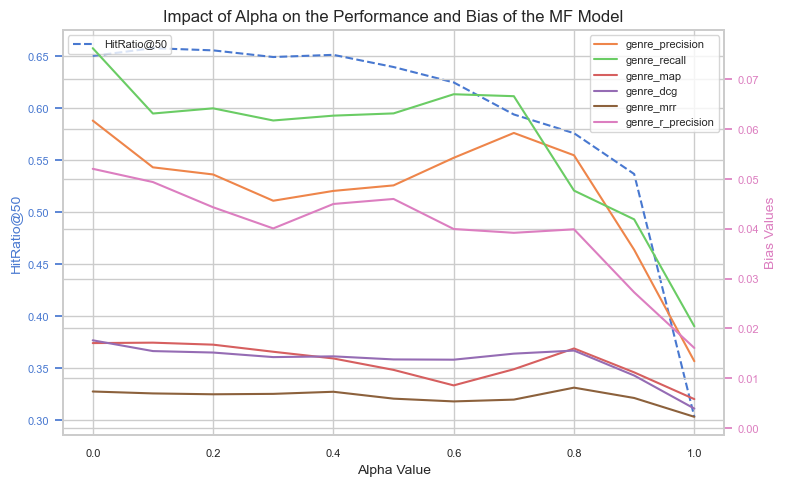

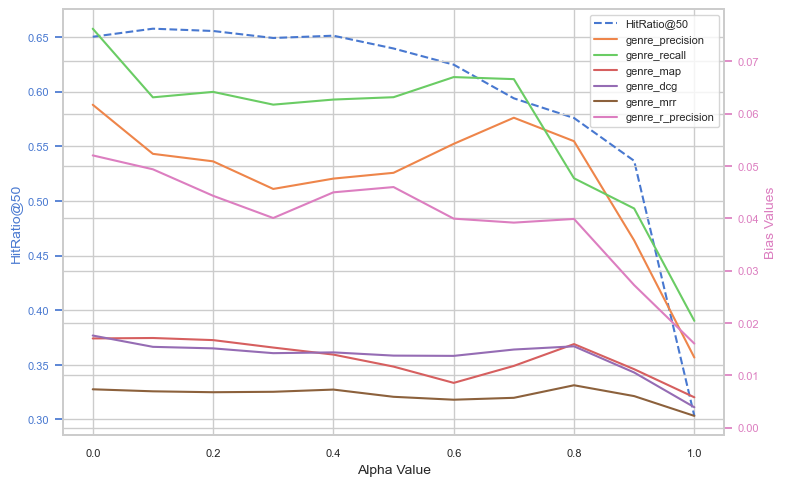

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

x = alpha_values
upper_bound = len(alpha_values)

# Set seaborn style and define a pastel color palette
sns.set(style="whitegrid")
pastel_palette = sns.color_palette("muted")

# Create a figure and a set of subplots
fig, ax1 = plt.subplots(figsize=(8, 5))  # Adjust figure size to make it more compact

# Plot the HitRatio@50
ax1.plot(x[0:upper_bound], hit_ratio_values_extracted[0:upper_bound], linestyle="--", color=pastel_palette[0], label="HitRatio@50")
ax1.set_xlabel("Alpha Value", fontsize=10)
ax1.set_ylabel("HitRatio@50", color=pastel_palette[0], fontsize=10)
ax1.tick_params(axis="y", colors=pastel_palette[0], labelsize=8)
ax1.tick_params(axis="x", labelsize=8)

# Create a secondary y-axis for bias values
ax2 = ax1.twinx()
ax2.plot(x[0:upper_bound], gp_sum[0:upper_bound], label=titles[0], color=pastel_palette[1])
ax2.plot(x[0:upper_bound], gr_sum[0:upper_bound], label=titles[1], color=pastel_palette[2])
ax2.plot(x[0:upper_bound], gm_sum[0:upper_bound], label=titles[2], color=pastel_palette[3])
ax2.plot(x[0:upper_bound], gdcg_sum[0:upper_bound], label=titles[3], color=pastel_palette[4])
ax2.plot(x[0:upper_bound], gmrr_sum[0:upper_bound], label=titles[4], color=pastel_palette[5])
ax2.plot(x[0:upper_bound], grp_sum[0:upper_bound], label=titles[5], color=pastel_palette[6])
ax2.set_ylabel("Bias Values", color=pastel_palette[6], fontsize=10)
ax2.tick_params(axis="y", colors=pastel_palette[6], labelsize=8)

# Adjust the legend font size and position to make it smaller and compact
ax1.legend(loc="upper left", fontsize=8)
ax2.legend(loc="upper right", fontsize=8)

# Set the title and adjust layout for compactness
plt.title("Impact of Alpha on the Performance and Bias of the MF Model", fontsize=12)
plt.tight_layout(pad=1)  # Reduce padding around the plot

# Show the plotimport matplotlib.pyplot as plt
import seaborn as sns

x = alpha_values
upper_bound = len(alpha_values)

# Set seaborn style and define a pastel color palette
sns.set(style="whitegrid")
pastel_palette = sns.color_palette("muted")

# Create a figure and a set of subplots
fig, ax1 = plt.subplots(figsize=(8, 5))  # Adjust figure size to make it more compact

# Plot the HitRatio@50
hitratio_line, = ax1.plot(x[0:upper_bound], hit_ratio_values_extracted[0:upper_bound], linestyle="--", color=pastel_palette[0], label="HitRatio@50")
ax1.set_xlabel("Alpha Value", fontsize=10)
ax1.set_ylabel("HitRatio@50", color=pastel_palette[0], fontsize=10)
ax1.tick_params(axis="y", colors=pastel_palette[0], labelsize=8)
ax1.tick_params(axis="x", labelsize=8)

# Create a secondary y-axis for bias values
ax2 = ax1.twinx()
gp_line, = ax2.plot(x[0:upper_bound], gp_sum[0:upper_bound], label=titles[0], color=pastel_palette[1])
gr_line, = ax2.plot(x[0:upper_bound], gr_sum[0:upper_bound], label=titles[1], color=pastel_palette[2])
gm_line, = ax2.plot(x[0:upper_bound], gm_sum[0:upper_bound], label=titles[2], color=pastel_palette[3])
gdcg_line, = ax2.plot(x[0:upper_bound], gdcg_sum[0:upper_bound], label=titles[3], color=pastel_palette[4])
gmrr_line, = ax2.plot(x[0:upper_bound], gmrr_sum[0:upper_bound], label=titles[4], color=pastel_palette[5])
grp_line, = ax2.plot(x[0:upper_bound], grp_sum[0:upper_bound], label=titles[5], color=pastel_palette[6])
ax2.set_ylabel("Bias Values", color=pastel_palette[6], fontsize=10)
ax2.tick_params(axis="y", colors=pastel_palette[6], labelsize=8)

# Combine legends from both axes
lines = [hitratio_line, gp_line, gr_line, gm_line, gdcg_line, gmrr_line, grp_line]
labels = [line.get_label() for line in lines]

# Set a single legend for both ax1 and ax2
ax2.legend(lines, labels, loc="upper right", fontsize=8)

# Set the title and adjust layout for compactness
# plt.title("Impact of Alpha on the Performance and Bias of the MF Model", fontsize=12)
plt.tight_layout(pad=1)  # Reduce padding around the plot
plt.savefig("ml_100k_reg.pdf", format="pdf")
# Show the plot
plt.show()

plt.show()


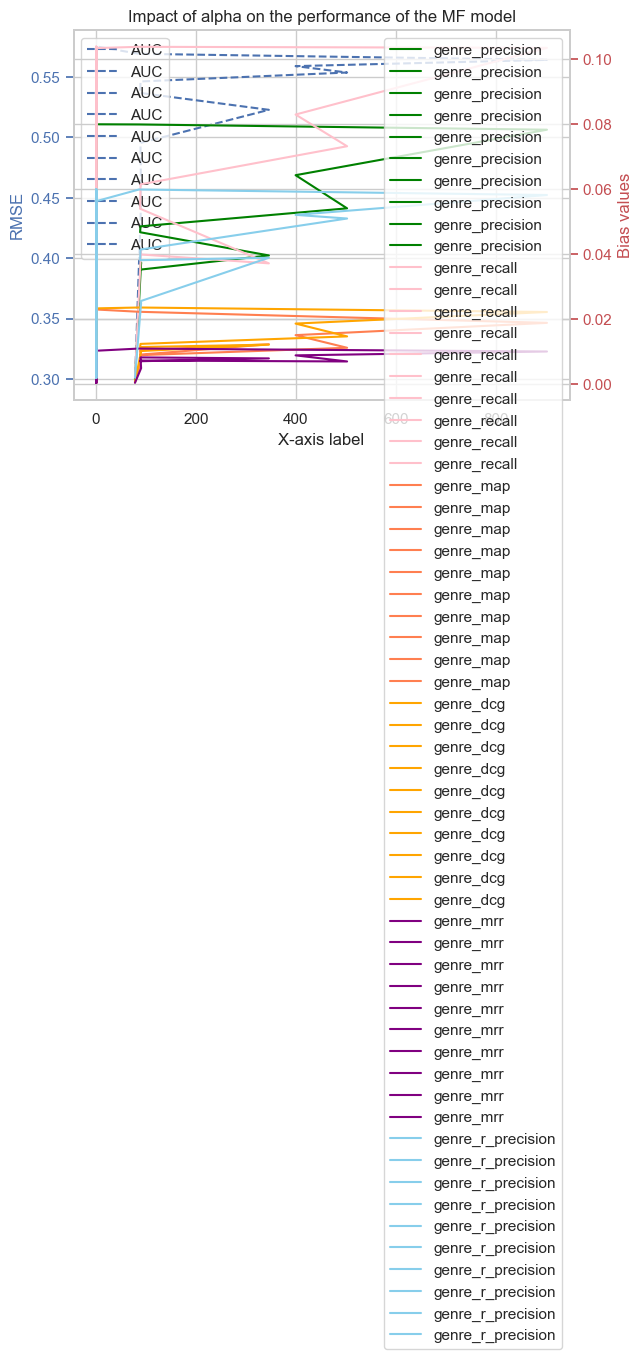

In [ ]:
import matplotlib.pyplot as plt

# Sample data
x = alpha_values


# Data for the primary y-axis
# Data for the secondary y-axis

# Create a figure and a set of subplots
fig, ax1 = plt.subplots()
upper_bound=13
# Plot data on the primary y-axis
# ax1.plot(x[0:upper_bound], auc_values_extracted[0:upper_bound],color= "skyblue", label="AUC")
ax1.plot(x[0:upper_bound], auc_values_extracted[0:upper_bound], "b--", label="AUC")
ax1.set_xlabel("X-axis label")
ax1.set_ylabel("RMSE", color="b")
ax1.tick_params("y", colors="b")

# Create a secondary y-axis
ax2 = ax1.twinx()
ax2.plot(x[0:upper_bound], gp_sum[0:upper_bound], label=titles[0], color="green")
ax2.plot(x[0:upper_bound], gr_sum[0:upper_bound], label=titles[1], color="pink")
ax2.plot(x[0:upper_bound], gm_sum[0:upper_bound], label=titles[2], color="coral")
ax2.plot(x[0:upper_bound], gdcg_sum[0:upper_bound], label=titles[3], color="orange")
ax2.plot(x[0:upper_bound], gmrr_sum[0:upper_bound], label=titles[4], color="purple")
ax2.plot(x[0:upper_bound], grp_sum[0:upper_bound], label=titles[5], color="skyblue")
ax2.set_ylabel("Bias values", color="r")
ax2.tick_params("y", colors="r")

# Add legends
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")

# Show the plot
plt.title("Impact of alpha on the performance of the MF model")
plt.show()

In [ ]:
top_k = 20
reco_matrix_n = np.zeros((len(user_ids), top_k), dtype=int)

for i in range(reco_matrix[0].shape[0]):
    reco_matrix_n[i] = reco_matrix[1][i][:top_k]

reco_matrix_n.shape

In [ ]:
reco_matrix[1].shape[0]
# top_k = 50
# reco_matrix = np.zeros((reco_matrix_all_items.shape[0], top_k), dtype=int)
# for i in range(reco_matrix_all_items.shape[0]):
#     reco_matrix[i] = reco_matrix_all_items[i][:top_k]

In [ ]:
sum(model_gdcg_2)

In [ ]:
# np.where(reco_matrix_mapped_items[1][0]==0)
# reco_matrix_all[1][0][258]
reco_matrix_mapped_scores[1][1][1552]

# reco_matrix_mapped_items[1][1][1552]
# reco_matrix_mapped_items[1][0][258]
# reco_items_scores_all[0]
# mapped_item_index

In [ ]:
reco_items_scores_all[0][0]
# np.save("reco_items_scores_all.npy",reco_items_scores_all)

In [ ]:
# unique_genres = ['Crime',
#  'Film-Noir',
#  'Adventure',
#  'Fantasy',
#  'Sci-Fi',
#  'Documentary',
#  'Drama',
#  'Horror',
#  'War',
#  'Animation',
#  'Romance',
#  "Children's",
#  'Western',
#  'Mystery',
#  'Thriller',
#  'Musical',
#  'Action',
#  'Comedy']

In [ ]:
# tahsin kheya
# last modified 21/07/2024
import pandas as pd
import os
import numpy as np
import torch
import time
from logging import getLogger
import random


class Calibration(object):
    def __init__(self, config, movies, top_k, unique_genres, users):
        self.device = "cuda:0" if torch.cuda.is_available() else "cpu"
        self.device = torch.device(self.device)
        # self.logger = getLogger()
        self.reco_distribution = []
        self.kl = []

        # self.logger = getLogger()
        self.top_k = top_k
        self.gkl = []
        self.gender_df = users
        self.actual_genre_dist = pd.read_csv(
            os.path.join(config["user_genre_dist_file"]),
            sep="\t",
        )
        self.unique_genres = list(self.actual_genre_dist.columns)[1:]

        # self.actual_genre_dist = self.actual_genre_dist.drop(columns=["userID"])

        self.config = config
        self.item_df = movies
        self.actual_distribution_without_id = self.actual_genre_dist.drop(
            columns=["userID"]
        ).to_numpy()
        print(self.unique_genres)
        # print(self.actual_distribution_without_id)

        self.actual_distribution_gender = []

    def get_all_user_recommended_genre_dist(self, topk_reco):

        df_reco = pd.DataFrame(
            {
                "userID": np.repeat(np.arange(topk_reco.shape[0]), self.top_k),
                "itemID": topk_reco.flatten(),
                "rank": np.tile(np.arange(1, self.top_k + 1), topk_reco.shape[0]),
            }
        )

        df_reco["weight_factor"] = 1 / (df_reco["rank"]) ** 0.1
        merged_df = pd.merge(df_reco, self.item_df, on="itemID", how="inner")
        merged_df[self.unique_genres] = merged_df[self.unique_genres].div(
            merged_df[self.unique_genres].sum(axis=1), axis=0
        )

        merged_df[self.unique_genres] = (
            merged_df["weight_factor"].values[:, None] * merged_df[self.unique_genres]
        )
        reco_distribution = merged_df[["userID"] + self.unique_genres]
        reco_distribution = reco_distribution.groupby("userID")[
            self.unique_genres
        ].mean()
        #         reco_distribution[self.unique_genres] = reco_distribution[
        #             self.unique_genres
        #         ].div(reco_distribution[self.unique_genres].sum(axis=1), axis=0)

        return reco_distribution

    def get_recom_distribution(self, reco):

        reco = np.array(reco)
        weights = 1 / (np.arange(len(reco)) + 1) ** 0.1
        item_genre_weights = np.zeros((len(reco), len(self.unique_genres)))

        for i, itemID in enumerate(reco):
            item_index = self.item_df.index.get_loc(itemID)
            item_genre_weights[i] = (
                weights[i] * self.item_df.loc[item_index, self.unique_genres]
            )
        #         print(item_genre_weights)
        # Normalize genre weights so sum is 1
        #         item_genre_weights /= torch.sum(item_genre_weights, axis=1, keepdims=True)

        return item_genre_weights

    def get_kl_div(self, q_dist, p_dist, a, uid):
        kl_div = 0
        qg_u = (1 - a) * q_dist + a * p_dist
        nonzero_indices = np.where(p_dist != 0)

        kl_div = np.sum(
            p_dist[nonzero_indices]
            * np.log10(p_dist[nonzero_indices] / qg_u[nonzero_indices])
        )

        return kl_div

    # def get_gender_representation_one_user(self, reco_dist, uid):
    #     c = []
    #     retVal = []
    #     print(self.actual_distribution[uid])

    #     for i in range(len(self.unique_genres)):
    #         c.append(np.log(reco_dist[i] / self.actual_distribution[uid][i + 1]))
    #     # Assuming self.unique_genres is a list or array-like
    #     genre_columns_count = len(self.unique_genres)

    #     reco_dist_slice = reco_dist[:genre_columns_count]
    #     actual_dist_slice = self.actual_distribution[uid][1 : genre_columns_count + 1]

    #     log_ratios = np.log(reco_dist_slice / actual_dist_slice)
    #     retVal.extend(log_ratios.tolist())

    def compute_diversity_score(self, reco_items, uid, l, scores, user_reco, b):

        # -----------------the diversity term----------------------------------
        alpha = 0.01
        # reco_items=self.reco_distribution[uid]
        sum_score = 0
        reco_dist = self.get_recom_distribution(reco_items)
        # print(reco_dist)
        #
        sum_dist = np.sum(reco_dist, axis=0)
        avg_dist = sum_dist / reco_dist.shape[0]
        # 1x18 array (it already is, but let's reshape explicitly)
        reco_dist = avg_dist.reshape(1, -1)
        # normalise values
        reco_dist = reco_dist / sum(reco_dist[0])
        # print(f"reco item {reco_items}, genre_dist_actual_user {self.actual_distribution_without_id[uid]}, reco genre distribution {reco_dist}")
        kl = self.get_kl_div(
            reco_dist[0], self.actual_distribution_without_id[uid], alpha, uid
        )

        # -----------------the diversity term----------------------------------

        # -----------------the fairness term----------------------------------
        # recommended dist mean for each gender
        male_user_ids = self.gender_df[self.gender_df["Gender"] == 0]["userID"]
        male_user_ids = male_user_ids.to_list()
        gender_genre_dist = self.actual_distribution_gender
        # gender_reco_dist = self.get_gender_representation_one_user(reco_dist[0],uid)
        if uid in male_user_ids:
            compare_dist = gender_genre_dist.to_numpy()[1]
        else:
            compare_dist = gender_genre_dist.to_numpy()[0]

        # gender_kl = self.get_kl_div(reco_dist[0], compare_dist, alpha, uid)
        gender_kl = 0

        # -----------------the fairness term----------------------------------

        for r in range(len(reco_items)):
            sum_score += scores[reco_items[r]]

        # print(f"genderkl {gender_kl}, kl {kl} score{sum_score}")

        # if len(reco_items) == 5:
        #     self.kl.append(kl)
        #     self.gkl.append(gender_kl)
        #     print(":;;;;;;;;;;;")
        #     print(uid)

        #     print(self.kl)
        #     print(self.gkl)
        #     print(":;;;;;;;;;;;")
        # print(f"score {sum_score}, kl {kl}, gender_kl {gender_kl}")

        return (1 - l - b) * sum_score - l * kl - b * gender_kl

    # c.get_improved_reco(reco_matrix,reco_matrix_all_items,reco_matrix_all_scores, users)

    def get_improved_reco(self, top_items, items, scores):

        # reco = torch.cat(batch_matrix_list, dim=0).cpu().numpy()

        # scores = torch.cat(batch_score_list, dim=0).cpu().numpy()
        # self.reco_distribution = self.get_recom_distribution(reco)
        return self.get_new_recommendations(
            reco=top_items, scores=scores, all_items=items
        )

    def get_kl_div_gender(self, female_dist, male_dist, a):
        kl_div = 0
        for i in range(len(self.unique_genres)):
            female_dist = (1 - a) * female_dist[i] + a * male_dist[i]
            if male_dist[i] == 0:
                continue
            kl_div = kl_div + male_dist[i] * np.log10(male_dist[i] / female_dist[i])

        return kl_div

    def get_gender_genre_dist(self, user_reco):
        # gender_df = pd.DataFrame(self.genders.items(), columns=["userID", "gender"])
        actual_dist_gender = pd.merge(
            self.actual_genre_dist, self.gender_df, on="userID"
        )
        recomen_df = pd.merge(user_reco, self.gender_df, on="userID")
        # gender_genre_weights_r = recomen_df.groupby("gender")[
        #     self.unique_genres
        # ].mean()
        gender_genre_weights_a = actual_dist_gender.groupby("Gender")[
            self.unique_genres
        ].mean()
        self.actual_distribution_gender = gender_genre_weights_a.sort_index()

    def get_new_recommendations(self, reco, scores, all_items):
        """reco is 6040x50 and scores is 6040x3416"""

        user_reco_dist = self.get_all_user_recommended_genre_dist(reco)
        self.get_gender_genre_dist(user_reco_dist)

        #####
        # gender_discriminated_agaisnt = self.get_gender_discriminated_agaisnt(
        #     user_reco_dist
        # )
        # male_user_ids = [user_id for user_id, gender in self.genders.items() if gender == 0]
        # female_user_ids = [user_id for user_id, gender in self.genders.items() if gender == 1]
        # for each gender clculate the skew for each genre:
        b = 0.69  # beta
        l = 0.29  # lambda
        all_users = []

        #####

        top_k = self.top_k

        n_users, n_items = all_items.shape

        for u in range(0, 50):
            # remaining_items = all_items
            remaining_items = list(all_items[u])
            # print(remaining_items)

            #             u_calibrated = [623, 1612, 558, 1087, 1347, 3368, 196, 3256, 3127, 882, 831, 1271, 1870, 2594, 3279, 2624, 393, 1496, 3099, 2414, 1232, 1773, 1313, 610, 500, 2855, 1973, 1872, 3334, 3296, 649, 769, 1573, 2474, 2133, 2161, 3387, 2640, 1583, 3287, 753, 384, 2192, 709, 1981, 3311 ]
            u_calibrated = []
            for k in range(top_k):
                diversity_scores = [
                    self.compute_diversity_score(
                        u_calibrated + [i], u, l, scores[u], user_reco_dist, b
                    )
                    for i in remaining_items
                ]
                max_index = np.argmax(diversity_scores)

                best_item = remaining_items[max_index]
                u_calibrated.append(best_item)
                remaining_items.pop(max_index)
                print(u_calibrated)
                # self.logger.info(u_calibrated)

            # self.logger.info(u_calibrated)

            all_users.append(u_calibrated)

        return np.array(all_users)

In [ ]:
reco_matrix_all[1].shape

In [ ]:
score_dicts[1][889]
reco_matrix_all[1][0][0]
score_dicts[1][0]

In [ ]:
# from cornac.reranking.Calibration import Calibration
config = {"user_genre_dist_file": "./cornac/data_c/user_genre_dist_new.csv"}
c = Calibration(
    config=config, movies=movies, top_k=50, unique_genres=unique_genres, users=users
)
# for itemknn

reranked_reco = c.get_improved_reco(reco_matrix[1], reco_matrix_all[1], score_dicts)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

matrices = MF_gm


values1 = matrices[0]
values2 = matrices[1]
# values2 = matrices[2]
# values2 = matrices[3]
# values3 = matrices[2]
labels = unique_genres
bar_width = 0.25
titles = ["MF_gp", "MF_gm"]


fig, axs = plt.subplots(2, 3, figsize=(18, 12))
axs = axs.flatten()


for i in range(len(matrices)):
    axs[i].bar(labels, matrices[i], color="skyblue")
    axs[i].set_title(titles[i])
    axs[i].set_xlabel("Genres")
    axs[i].set_ylabel("Values")
    axs[i].tick_params(axis="x", rotation=90)

# Adjust layout
plt.tight_layout()
plt.show()

In [ ]:
print(user_features_numpy[:, 1].shape)

In [ ]:
# Calculate total number of genres
total_genres = len(unique_genres)  # Exclude 'itemID'
# Assuming 'column_name' is the name of the column you want to convert to float
movies[unique_genres] = movies[unique_genres].astype(float)

# Iterate over each row
for index, row in movies.iterrows():
    # Find genres with value 1
    present_genres = [genre for genre in unique_genres if row[genre] == 1]
    num_present_genres = len(present_genres)

    # Calculate weight for each present genre
    if num_present_genres > 0:
        weight_per_genre = 1 / num_present_genres
        for genre in present_genres:
            if movies.at[index, genre] == 1:
                movies.at[index, genre] = weight_per_genre

In [ ]:
# mergde_pd = pd.merge(rating_data_pd,users, how="inner", on="userID")
mergde_pd = pd.merge(rating_data_pd, movies, how="inner", on="itemID")
mergde_pd

In [ ]:
user_genre_means = mergde_pd.groupby("userID")[unique_genres].mean()
user_genre_means

In [ ]:
users

In [ ]:
useer = pd.merge(user_genre_means, users, on="userID", how="inner")
user_genre_gender = useer.groupby("Gender")[unique_genres].mean()
user_genre_gender

In [ ]:
rating_data_pd

In [ ]:
# inter_movies
z = inter_movies[["userID", "itemID", "Gender"]]
mergz = pd.merge(z, movies, on="itemID", how="left")
mergz
user_genre_gender = mergz.groupby("Gender")[unique_genres].mean()
user_genre_gender

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Plotting
x = np.arange(len(unique_genres))  # the label locations
bar_width = 0.1  # the width of the bars

fig, ax = plt.subplots(figsize=(12, 6))  # Set the figure size

# Plot the data
rects1 = ax.bar(
    x - 3 * bar_width / 2,
    user_genre_gender.iloc[0] * 100,
    bar_width,
    label="male (Top 50)",
    color="#bca0dc",
)
rects2 = ax.bar(
    x + bar_width / 2,
    user_genre_gender.iloc[1] * 100,
    bar_width,
    label="feMale (Top 50)",
    color="#ff3c00",
)

# rects3 = ax.bar(x - 5*bar_width/2, gender_genre_weights_topk_over.iloc[0]*100, bar_width, label='Female (over sampled )',color="#4d9fff")
# rects4 = ax.bar(x + 5*bar_width/2, gender_genre_weights_topk_over.iloc[1]*100, bar_width, label='Male (over sampled )',color="#78eaff")

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel("Genres", fontsize=14)
ax.set_ylabel("% Values", fontsize=14)
ax.set_title("Values by Genre and Gender top 50 vs All Data", fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(unique_genres, rotation=90, fontsize=12)
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Plotting
x = np.arange(len(unique_genres))  # the label locations
bar_width = 0.1  # the width of the bars

fig, ax = plt.subplots(figsize=(12, 6))  # Set the figure size

# Plot the data
rects1 = ax.bar(
    x - 3 * bar_width / 2,
    user_genre_gender.iloc[0] * 100,
    bar_width,
    label="male (Top 50)",
    color="#bca0dc",
)
rects2 = ax.bar(
    x + bar_width / 2,
    user_genre_gender.iloc[1] * 100,
    bar_width,
    label="female (Top 50)",
    color="#ff3c00",
)

# rects3 = ax.bar(x - 5*bar_width/2, gender_genre_weights_topk_over.iloc[0]*100, bar_width, label='Female (over sampled )',color="#4d9fff")
# rects4 = ax.bar(x + 5*bar_width/2, gender_genre_weights_topk_over.iloc[1]*100, bar_width, label='Male (over sampled )',color="#78eaff")

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel("Genres", fontsize=14)
ax.set_ylabel("% Values", fontsize=14)
ax.set_title("Values by Genre and Gender top 50 vs All Data", fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(unique_genres, rotation=90, fontsize=12)
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
# inter_movies["itemID"].nunique()
reco_matrix_new.shape

In [ ]:
# Generate userID array
user_ids = np.arange(1, reco_matrix_new.shape[0] + 1).repeat(reco_matrix_new.shape[1])

# Flatten movie_ids array
flat_movie_ids = reco_matrix_new.flatten()

# Create DataFrame
df = pd.DataFrame({"userID": user_ids, "itemID": flat_movie_ids})

mepd = pd.merge(df, movies, on="itemID", how="inner")
mepd = pd.merge(mepd, users, on="userID", how="inner")
user_genre_gender_1 = mepd.groupby("Gender")[unique_genres].mean()

user_genre_gender_1
# Print the DataFrame

In [ ]:
# Generate userID array
user_ids = np.arange(1, reco_matrix[1].shape[0] + 1).repeat(reco_matrix[1].shape[1])

# Flatten movie_ids array
flat_movie_ids = reco_matrix[1].flatten()

# Create DataFrame
df = pd.DataFrame({"userID": user_ids, "itemID": flat_movie_ids})

mepd = pd.merge(df, movies, on="itemID", how="inner")
mepd = pd.merge(mepd, users, on="userID", how="inner")
user_genre_gender_2 = mepd.groupby("Gender")[unique_genres].mean()

user_genre_gender_2
# Print the DataFrame

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Plotting
x = np.arange(len(unique_genres))  # the label locations
bar_width = 0.1  # the width of the bars

fig, ax = plt.subplots(figsize=(12, 6))  # Set the figure size

# Plot the data
rects1 = ax.bar(
    x - 3 * bar_width / 2,
    user_genre_gender_1.iloc[0] * 100,
    bar_width,
    label="Female (Top 50)",
    color="#bca0dc",
)
rects2 = ax.bar(
    x + bar_width / 2,
    user_genre_gender_1.iloc[1] * 100,
    bar_width,
    label="Male (Top 50)",
    color="#ff3c00",
)

# rects3 = ax.bar(x - 5*bar_width/2, gender_genre_weights_topk_over.iloc[0]*100, bar_width, label='Female (over sampled )',color="#4d9fff")
# rects4 = ax.bar(x + 5*bar_width/2, gender_genre_weights_topk_over.iloc[1]*100, bar_width, label='Male (over sampled )',color="#78eaff")

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel("Genres", fontsize=14)
ax.set_ylabel("% Values", fontsize=14)
ax.set_title("Values by Genre and Gender top 50 vs All Data", fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(unique_genres, rotation=90, fontsize=12)
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Plotting
x = np.arange(len(unique_genres))  # the label locations
bar_width = 0.1  # the width of the bars

fig, ax = plt.subplots(figsize=(12, 6))  # Set the figure size

# Plot the data
rects1 = ax.bar(
    x - 3 * bar_width / 2,
    user_genre_gender_1.iloc[0] * 100,
    bar_width,
    label="Female (Top 50)",
    color="#bca0dc",
)
rects2 = ax.bar(
    x + bar_width / 2,
    user_genre_gender_1.iloc[1] * 100,
    bar_width,
    label="Male (Top 50)",
    color="#ff3c00",
)

# rects3 = ax.bar(x - 5*bar_width/2, gender_genre_weights_topk_over.iloc[0]*100, bar_width, label='Female (over sampled )',color="#4d9fff")
# rects4 = ax.bar(x + 5*bar_width/2, gender_genre_weights_topk_over.iloc[1]*100, bar_width, label='Male (over sampled )',color="#78eaff")

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel("Genres", fontsize=14)
ax.set_ylabel("% Values", fontsize=14)
ax.set_title("Values by Genre and Gender top 50 vs All Data", fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(unique_genres, rotation=90, fontsize=12)
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
##use 0 and 0.5 as alpha

In [ ]:
# Generate userID array
user_ids = np.arange(1, reco_matrix[1].shape[0] + 1).repeat(reco_matrix[1].shape[1])

# Flatten movie_ids array
flat_movie_ids = reco_matrix[1].flatten()

# Create DataFrame
df = pd.DataFrame({"userID": user_ids, "itemID": flat_movie_ids})

mepd = pd.merge(df, movies, on="itemID", how="inner")
mepd = pd.merge(mepd, users, on="userID", how="inner")
user_genre_gender_1 = mepd.groupby("Gender")[unique_genres].mean()

user_genre_gender_1
# Print the DataFrame

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Plotting
x = np.arange(len(unique_genres))  # the label locations
bar_width = 0.1  # the width of the bars

fig, ax = plt.subplots(figsize=(12, 6))  # Set the figure size

# Plot the data
rects1 = ax.bar(
    x - 3 * bar_width / 2,
    user_genre_gender_1.iloc[0] * 100,
    bar_width,
    label="Female (Top 50)",
    color="#bca0dc",
)
rects2 = ax.bar(
    x + bar_width / 2,
    user_genre_gender_1.iloc[1] * 100,
    bar_width,
    label="Male (Top 50)",
    color="#ff3c00",
)

# rects3 = ax.bar(x - 5*bar_width/2, gender_genre_weights_topk_over.iloc[0]*100, bar_width, label='Female (over sampled )',color="#4d9fff")
# rects4 = ax.bar(x + 5*bar_width/2, gender_genre_weights_topk_over.iloc[1]*100, bar_width, label='Male (over sampled )',color="#78eaff")

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel("Genres", fontsize=14)
ax.set_ylabel("% Values", fontsize=14)
ax.set_title("Values by Genre and Gender top 50 vs All Data", fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(unique_genres, rotation=90, fontsize=12)
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
inter_movies

In [ ]:
inter_movies.to_csv("biased_movie_lens.csv")

In [ ]:
movies_df

In [ ]:

np.save('reco_matrix.npy', reco_matrix)
np.save('reco_matrix_mapped_items.npy', reco_matrix_mapped_items)
np.save('reco_matrix_mapped_scores.npy', reco_matrix_mapped_scores)
np.save('reco_matrix_all.npy', reco_matrix_all)np.save('reco_items_scores_all.npy' , reco_matrix_all_edited)

#reco_matrix_all_items

In [ ]:
import torch

In [ ]:
t = torch.tensor([[0.2500, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.2500, 0.0000, 0.0000, 0.0000, 0.2500, 0.0000, 0.0000, 0.0000, 0.2500],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.5000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.5000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.5000, 0.0000, 0.5000],
        [0.0000, 0.0000, 0.3333, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.3333, 0.0000, 0.0000, 0.0000, 0.0000, 0.3333, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.3333, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.3333, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.3333, 0.0000],
        [0.2500, 0.0000, 0.2500, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.2500, 0.0000, 0.2500],
        [0.0000, 0.0000, 0.5000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.5000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 1.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 1.0000],
        [0.0000, 1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 1.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 1.0000],
        [0.0000, 0.0000, 0.5000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.5000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 1.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.5000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.5000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3333, 0.0000, 0.0000, 0.3333, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.3333, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3333, 0.3333, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.3333],
        [0.5000, 0.5000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.5000],
        [0.5000, 0.5000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.3333, 0.0000, 0.0000, 0.3333, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.3333],
        [0.0000, 0.3333, 0.0000, 0.0000, 0.0000, 0.3333, 0.0000, 0.0000, 0.0000,
         0.3333, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.3333, 0.0000, 0.0000, 0.0000, 0.3333, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.3333, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.3333, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.3333, 0.0000, 0.3333, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.3333, 0.0000, 0.3333, 0.0000, 0.0000,
         0.3333, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5000, 0.5000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 1.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 1.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 1.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3333, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.3333, 0.3333, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.5000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 1.0000],
        [0.0000, 1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.5000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.5000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 1.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.3333, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.3333, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.3333],
        [0.0000, 0.3333, 0.0000, 0.0000, 0.0000, 0.3333, 0.0000, 0.3333, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.5000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 1.0000],
        [1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.2500, 0.0000, 0.0000, 0.0000,
         0.2500, 0.0000, 0.0000, 0.0000, 0.2500, 0.0000, 0.0000, 0.0000, 0.2500],
        [0.0000, 0.5000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.5000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000]])

In [ ]:
x=t[..., 1].sum()

In [ ]:
x

tensor(6.1665)

In [ ]:
model_gps[0]

NameError: name 'model_gps' is not defined